In [14]:
import os
import sys
from pathlib import Path

current = Path.cwd()
project_root = None
for candidate in [current, *current.parents]:
    if (candidate / "nasarbadi_helper.py").exists():
        project_root = candidate
        break

if project_root is None:
    project_root = current

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)

import mne
import pandas as pd
import matplotlib.pyplot as plt
import nasarbadi_helper


In [15]:
import os
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "nasarbadi_helper.py").exists():
    for candidate in project_root.parents:
        if (candidate / "nasarbadi_helper.py").exists():
            project_root = candidate
            break

os.chdir(project_root)
all_subjects = pd.read_csv(project_root / "datasets" / "metadata" / "nasarbadi_subject_index.csv")["ID"].tolist()


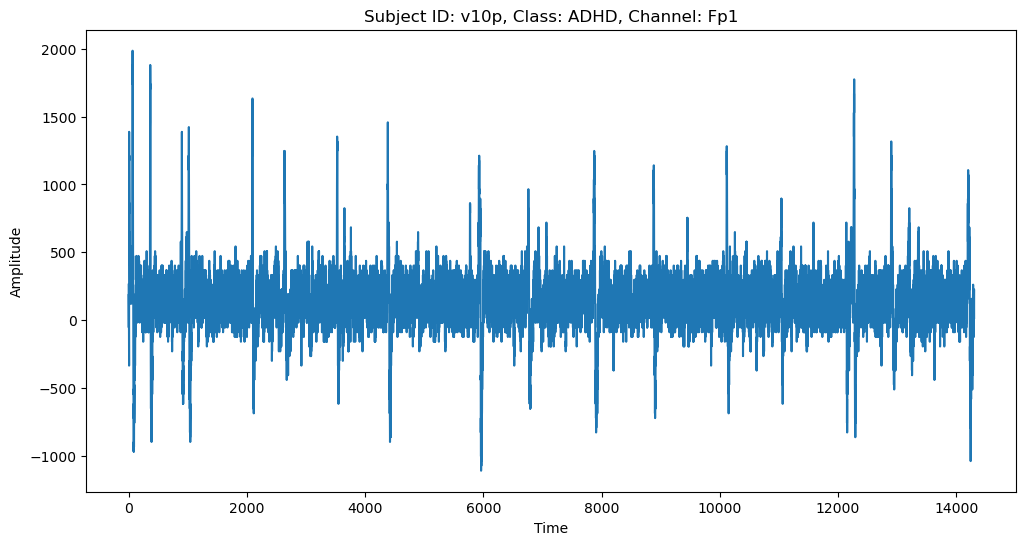

In [16]:
subject_id = all_subjects[0]
subject_data, class_label = nasarbadi_helper.get_subject_info(subject_id)

# Plot the signal of the first channel
plt.figure(figsize=(12, 6))
subject_data.iloc[:, 0].plot(title=f"Subject ID: {subject_id}, Class: {class_label}, Channel: {subject_data.columns[0]}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()
